# 03. Các Mô Hình Deep Learning

Huấn luyện CNN, LSTM và SimpleRNN trên raw URL string (char-level tokenization).  
Khác với notebook 02, các model ở đây học trực tiếp từ chuỗi ký tự thay vì 59 engineered features.

**Models:** LSTM · CNN · SimpleRNN

## 1. Setup

In [12]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score,
                              precision_score, recall_score)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential

df = pd.read_csv('../final_dataset_with_all_features_v3.1.csv')
df_seq = df[['url', 'label']].copy()

MAX_VOCAB = 10000
MAX_LEN = 200

# --- FIX: strip scheme để loại bỏ artifact http/https gây leak label ---
def strip_scheme(url):
    return re.sub(r'^https?://', '', str(url))

df_seq['url_clean'] = df_seq['url'].apply(strip_scheme)

tokenizer = Tokenizer(num_words=MAX_VOCAB, char_level=True)
tokenizer.fit_on_texts(df_seq['url_clean'])

X_seq = pad_sequences(tokenizer.texts_to_sequences(df_seq['url_clean']),
                      maxlen=MAX_LEN, padding='post', truncating='post')
y_seq = df_seq['label'].values

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)

print(f"X_train_seq: {X_train_seq.shape}")
print(f"X_test_seq:  {X_test_seq.shape}")

X_train_seq: (520952, 200)
X_test_seq:  (130239, 200)


## 2. Hàm Đánh Giá Chung

In [13]:
def evaluate_model(name, y_test, y_pred):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*45}")
    print(f"{name}")
    print(f"{'='*45}")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%")
    print(f"Recall   : {rec*100:.2f}%")
    print(f"F1-Score : {f1*100:.2f}%")
    print(f"\n{classification_report(y_test, y_pred, zero_division=0)}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign','Defacement','Phishing','Malware'],
                yticklabels=['Benign','Defacement','Phishing','Malware'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {'Mô hình': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1}

results = []

## 3. LSTM

c:\Project\malicious-url-detection\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 378s 231ms/step - accuracy: 0.6578 - loss: 0.9882 - val_accuracy: 0.6621 - val_loss: 0.9787
Epoch 2/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 1927s 1s/step - accuracy: 0.8451 - loss: 0.4416 - val_accuracy: 0.8713 - val_loss: 0.3517
Epoch 3/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 399s 245ms/step - accuracy: 0.9053 - loss: 0.2618 - val_accuracy: 0.9166 - val_loss: 0.2301
Epoch 4/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 426s 261ms/step - accuracy: 0.9165 - loss: 0.2337 - val_accuracy: 0.8190 - val_loss: 0.4844
Epoch 5/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 341s 209ms/step - accuracy: 0.8996 - loss: 0.2831 - val_accuracy: 0.9170 - val_loss: 0.2323
Epoch 6/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 419s 257ms/step - accuracy: 0.9209 - loss: 0.2204 - val_accuracy: 0.9251 - val_loss: 0.2073
Epoch 7/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 435s 267ms/step - accuracy: 0.9278 - loss: 0.2003 - val_accuracy: 0.9322 - val_loss: 0.1875
Epoch 8/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 2974s 2s/step - accura

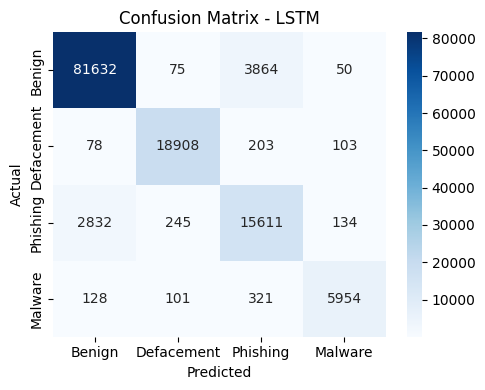

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

lstm_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

lstm_model.fit(X_train_seq, y_train_seq,
               epochs=10, batch_size=256,
               validation_split=0.2, verbose=1)

y_pred_lstm = lstm_model.predict(X_test_seq).argmax(axis=1)
results.append(evaluate_model('LSTM', y_test_seq, y_pred_lstm))

## 4. CNN

Dùng `Conv1D` để phát hiện các pattern cục bộ trong chuỗi ký tự phù hợp với URL vì các dấu hiệu độc hại thường nằm ở đoạn ngắn như `/login`, `.exe`, `@`.

Epoch 1/10


c:\Project\malicious-url-detection\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1628/1628 ━━━━━━━━━━━━━━━━━━━━ 64s 39ms/step - accuracy: 0.8466 - loss: 0.4054 - val_accuracy: 0.8915 - val_loss: 0.2870
Epoch 2/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.9001 - loss: 0.2591 - val_accuracy: 0.9066 - val_loss: 0.2460
Epoch 3/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 74s 45ms/step - accuracy: 0.9136 - loss: 0.2228 - val_accuracy: 0.9148 - val_loss: 0.2198
Epoch 4/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 77s 47ms/step - accuracy: 0.9206 - loss: 0.2040 - val_accuracy: 0.9163 - val_loss: 0.2162
Epoch 5/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 85s 52ms/step - accuracy: 0.9260 - loss: 0.1896 - val_accuracy: 0.9229 - val_loss: 0.1976
Epoch 6/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 164s 101ms/step - accuracy: 0.9294 - loss: 0.1806 - val_accuracy: 0.9215 - val_loss: 0.2056
Epoch 7/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 74s 45ms/step - accuracy: 0.9320 - loss: 0.1726 - val_accuracy: 0.9251 - val_loss: 0.1916
Epoch 8/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 73s 45ms/step - accuracy: 0.9342 - loss: 0.

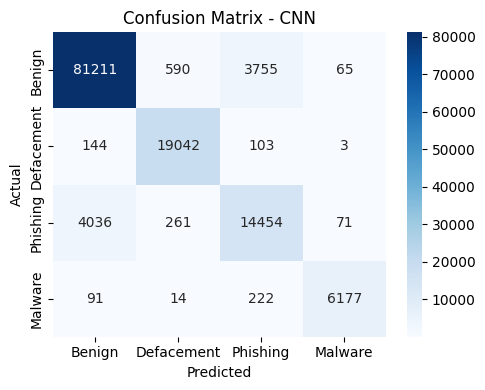

In [14]:
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Flatten, Dense

cnn_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.fit(X_train_seq, y_train_seq,
              epochs=10, batch_size=256,
              validation_split=0.2, verbose=1)

y_pred_cnn = cnn_model.predict(X_test_seq).argmax(axis=1)
results.append(evaluate_model('CNN', y_test_seq, y_pred_cnn))

In [16]:
from sklearn.metrics import classification_report

y_pred_cnn = cnn_model.predict(X_test_seq).argmax(axis=1)

print(classification_report(
    y_test_seq, y_pred_cnn,
    target_names=['Benign', 'Defacement', 'Phishing', 'Malware']
))

4070/4070 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
              precision    recall  f1-score   support

      Benign       0.95      0.95      0.95     85621
  Defacement       0.96      0.99      0.97     19292
    Phishing       0.78      0.77      0.77     18822
     Malware       0.98      0.95      0.96      6504

    accuracy                           0.93    130239
   macro avg       0.92      0.91      0.91    130239
weighted avg       0.93      0.93      0.93    130239



In [17]:
import requests

phishing_samples = df_seq[df_seq['label'] == 2]['url_clean'].sample(10, random_state=2).to_list()

for url in phishing_samples:
    full_url = 'http://' + url
    r = requests.post("http://127.0.0.1:8000/predict", json={"url": full_url})
    d = r.json()
    print(f"{d['label']:12} {d['confidence']:.3f}  {full_url}")

Phishing     0.738  http://members.multimania.nl/njh/
Phishing     0.833  http://poledancerfishingcharters.com/wp-content/plugins/jetpack/views/lloyds/login.html
Phishing     0.894  http://ltunes-updates.com/2df3a72a9af7d03ca768d76dbe8dbfb4/bf79b318311391bee949097a889d91f4/bb60373d9f2463fc56c2b81f0a48adb7/
Phishing     0.858  http://jguru.com/learn/
Phishing     0.998  http://id8-eu.co.uk/identify-customer=0rY87mECpUtYL8Tm60YwLG9VOMVKZLhO2j4E7z2QBECHHWwQm2nOCUjDKFkEAQCjo0281IjLGZHjolrS9k6fZtY1lvwyIkyxPKqw/
Phishing     0.906  http://nanomag.co.kr/eng/
Phishing     0.566  http://cbtcafe.com/dreamweaver/
Benign       0.990  http://fedraquintanilla1.cmail3.com/t/j-l-wllpk-yhdlkrtyj-t/
Phishing     0.969  http://dreamsworld.com.br
Phishing     0.939  http://asm.sourceforge.net/howto.html


In [21]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_probs_malicious = 1 - cnn_model.predict(X_test_seq)[:, 0]
y_true_malicious = (y_test_seq != 0).astype(int)

precision, recall, thresholds = precision_recall_curve(y_true_malicious, y_probs_malicious)

for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    idx = np.argmin(np.abs(thresholds - t))
    print(f"threshold={t:.1f}  precision={precision[idx]:.3f}  recall={recall[idx]:.3f}")

4070/4070 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
threshold=0.2  precision=0.795  recall=0.961
threshold=0.3  precision=0.839  recall=0.944
threshold=0.4  precision=0.873  recall=0.927
threshold=0.5  precision=0.900  recall=0.907
threshold=0.6  precision=0.924  recall=0.883
threshold=0.7  precision=0.944  recall=0.857


In [ ]:
import json
import pickle

# 1. Export model
cnn_model.save("url_cnn_model.keras")

# 2. Export tokenizer nguyên bản — QUAN TRỌNG: dùng pickle, không convert sang JSON
#    vì cần giữ đúng object Tokenizer để gọi lại texts_to_sequences() y hệt lúc train
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# 3. Export config còn lại (không cần char2idx nữa, dùng tokenizer trực tiếp)
config = {
    "max_len": MAX_LEN,
    "padding": "post",
    "truncating": "post",
    "class_labels": ["Benign", "Defacement", "Phishing", "Malware"]
}
with open("preprocessing_config.json", "w") as f:
    json.dump(config, f)

Done. Files: url_cnn_model.keras, tokenizer.pkl, preprocessing_config.json


## 5. SimpleRNN

Epoch 1/10


c:\Project\malicious-url-detection\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1628/1628 ━━━━━━━━━━━━━━━━━━━━ 135s 82ms/step - accuracy: 0.6574 - loss: 0.9796 - val_accuracy: 0.6608 - val_loss: 0.9581
Epoch 2/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 127s 78ms/step - accuracy: 0.6672 - loss: 0.9427 - val_accuracy: 0.7506 - val_loss: 0.6681
Epoch 3/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 117s 72ms/step - accuracy: 0.7514 - loss: 0.6665 - val_accuracy: 0.8029 - val_loss: 0.5510
Epoch 4/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 118s 73ms/step - accuracy: 0.7976 - loss: 0.5562 - val_accuracy: 0.7206 - val_loss: 0.7112
Epoch 5/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 3441s 2s/step - accuracy: 0.7535 - loss: 0.6724 - val_accuracy: 0.7528 - val_loss: 0.6584
Epoch 6/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 84s 52ms/step - accuracy: 0.7602 - loss: 0.6493 - val_accuracy: 0.7319 - val_loss: 0.6892
Epoch 7/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 93s 57ms/step - accuracy: 0.7468 - loss: 0.6793 - val_accuracy: 0.7547 - val_loss: 0.6551
Epoch 8/10
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 125s 77ms/step - accuracy: 0.7601 - loss:

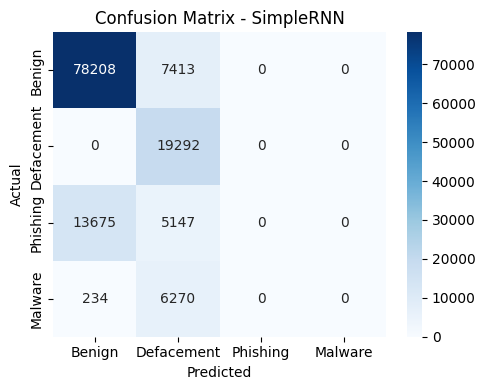

In [6]:
from tensorflow.keras.layers import SimpleRNN

rnn_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

rnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

rnn_model.fit(X_train_seq, y_train_seq,
              epochs=10, batch_size=256,
              validation_split=0.2, verbose=1)

y_pred_rnn = rnn_model.predict(X_test_seq).argmax(axis=1)
results.append(evaluate_model('SimpleRNN', y_test_seq, y_pred_rnn))

## 6. So Sánh Các Mô Hình Deep Learning

In [13]:
def evaluate_model(name, y_test, y_pred):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    return {'Mô hình': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1}

print("=== BẢNG SO SÁNH CÁC MÔ HÌNH DEEP LEARNING ===")
print(df_dl_results.to_string())

=== BẢNG SO SÁNH CÁC MÔ HÌNH DEEP LEARNING ===
     Mô hình Accuracy Precision  Recall F1-Score
1        CNN   96.07%    96.02%  96.07%   96.04%
2       LSTM   93.75%    93.92%  93.75%   93.82%
3  SimpleRNN   74.86%    63.31%  74.86%   67.81%
